In [1]:
! pip install gymnasium

In [2]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque

In [3]:
if torch.cuda.is_available():
    dev = "cuda:0"
elif torch.backends.mps.is_available():
    dev = "mps"
else:
    dev = "cpu"
device = torch.device(dev)
device

device(type='mps')

In [4]:
device = torch.device("cpu")
device

device(type='cpu')

In [5]:
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(QNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, action_dim)
        )

    def forward(self, x):
        return self.net(x)

In [6]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = map(np.array, zip(*batch))
        return state, action, reward, next_state, done

    def __len__(self):
        return len(self.buffer)

In [7]:
class DQNAgent:
    def __init__(self, state_dim, action_dim, device):
        self.device = device
        self.action_dim = action_dim
        
        self.q_net = QNetwork(state_dim, action_dim).to(device)
        self.target_net = QNetwork(state_dim, action_dim).to(device)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.q_net.parameters(), lr=5e-4)
        self.memory = ReplayBuffer(10000)

        self.gamma = 0.99
        self.batch_size = 64
        self.epsilon = 1.0
        self.epsilon_decay = 0.995
        self.epsilon_min = 0.01
        self.update_target_every = 500
        self.step_count = 0

    def select_action(self, state):
        if random.random() < self.epsilon:
            return random.randrange(self.action_dim)
        
        state = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        with torch.no_grad():
            q_values = self.q_net(state)
        return q_values.argmax().item()

    def train(self):
        if len(self.memory) < self.batch_size:
            return
        
        states, actions, rewards, next_states, dones = \
            self.memory.sample(self.batch_size)

        states = torch.FloatTensor(states).to(self.device)
        actions = torch.LongTensor(actions).unsqueeze(1).to(self.device)
        rewards = torch.FloatTensor(rewards).unsqueeze(1).to(self.device)
        next_states = torch.FloatTensor(next_states).to(self.device)
        dones = torch.FloatTensor(dones).unsqueeze(1).to(self.device)

        # Current Q values
        q_values = self.q_net(states).gather(1, actions)

        # Target Q values
        with torch.no_grad():
            next_q_values = self.target_net(next_states).max(1, keepdim=True)[0]
            target_q = rewards + self.gamma * next_q_values * (1 - dones)

        loss = nn.SmoothL1Loss()(q_values, target_q)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # Update target network
        self.step_count += 1
        if self.step_count % self.update_target_every == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())

In [8]:
import gymnasium as gym

env = gym.make("CartPole-v1")

agent = DQNAgent(
    state_dim=env.observation_space.shape[0],
    action_dim=env.action_space.n,
    device=device
)

num_episodes = 1000

episode_rewards = []

best_avg_reward = -float('inf')  # track best moving average
window = 20  # moving average window

for episode in range(num_episodes):
    state, _ = env.reset()
    total_reward = 0
    done = False
    step_count = 0

    while not done:
        action = agent.select_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        agent.memory.push(state, action, reward, next_state, done)
        agent.train()

        state = next_state
        total_reward += reward
        step_count += 1

    agent.epsilon = max(agent.epsilon_min, agent.epsilon * agent.epsilon_decay)
    episode_rewards.append(total_reward)

    # Compute moving average
    if len(episode_rewards) >= window:
        moving_avg = np.mean(episode_rewards[-window:])
        # Save best network based on moving average
        if moving_avg > best_avg_reward:
            best_avg_reward = moving_avg
            torch.save(agent.q_net.state_dict(), "best_dqn.pth")

    print(f"Episode {episode} | Reward: {total_reward} | Moving Avg: {moving_avg if len(episode_rewards) >= window else total_reward:.2f} | Epsilon: {agent.epsilon:.3f}")

Episode 0 | Reward: 11.0 | Moving Avg: 11.00 | Epsilon: 0.995
Episode 1 | Reward: 15.0 | Moving Avg: 15.00 | Epsilon: 0.990
Episode 2 | Reward: 33.0 | Moving Avg: 33.00 | Epsilon: 0.985
Episode 3 | Reward: 15.0 | Moving Avg: 15.00 | Epsilon: 0.980
Episode 4 | Reward: 25.0 | Moving Avg: 25.00 | Epsilon: 0.975
Episode 5 | Reward: 35.0 | Moving Avg: 35.00 | Epsilon: 0.970
Episode 6 | Reward: 13.0 | Moving Avg: 13.00 | Epsilon: 0.966
Episode 7 | Reward: 25.0 | Moving Avg: 25.00 | Epsilon: 0.961
Episode 8 | Reward: 17.0 | Moving Avg: 17.00 | Epsilon: 0.956
Episode 9 | Reward: 11.0 | Moving Avg: 11.00 | Epsilon: 0.951
Episode 10 | Reward: 12.0 | Moving Avg: 12.00 | Epsilon: 0.946
Episode 11 | Reward: 10.0 | Moving Avg: 10.00 | Epsilon: 0.942
Episode 12 | Reward: 15.0 | Moving Avg: 15.00 | Epsilon: 0.937
Episode 13 | Reward: 24.0 | Moving Avg: 24.00 | Epsilon: 0.932
Episode 14 | Reward: 63.0 | Moving Avg: 63.00 | Epsilon: 0.928
Episode 15 | Reward: 16.0 | Moving Avg: 16.00 | Epsilon: 0.923
Ep

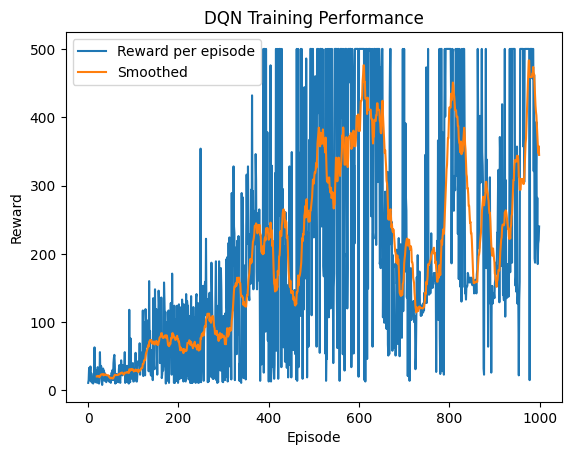

In [9]:
import matplotlib.pyplot as plt
import numpy as np

plt.plot(episode_rewards, label="Reward per episode")

# Optional smoothing
window = 20
smoothed = np.convolve(
    episode_rewards,
    np.ones(window)/window,
    mode='valid'
)
plt.plot(range(window-1, len(episode_rewards)), smoothed, label="Smoothed")

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("DQN Training Performance")
plt.legend()
plt.show()

In [10]:
agent.q_net.load_state_dict(torch.load("best_dqn.pth"))
agent.epsilon = 0.0  # no exploration

In [11]:
num_eval_episodes = 100
episode_lengths = []

for episode in range(num_eval_episodes):
    state, _ = env.reset()
    done = False
    steps = 0

    while not done:
        action = agent.select_action(state)
        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        steps += 1

    episode_lengths.append(steps)

env.close()

average_steps = sum(episode_lengths) / num_eval_episodes
print(f"Average steps over {num_eval_episodes} episodes: {average_steps:.2f}")

Average steps over 100 episodes: 500.00


In [12]:
! pip install gymnasium[classic-control]

In [13]:
env = gym.make("CartPole-v1", render_mode="human")

state, _ = env.reset()
done = False

while not done:
    action = agent.select_action(state)
    state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated

env.close()